This is the combined homework for the ML class 2025. It has max 50 points.

It has max 50 points. The deadline is 2 weeks from now (17 Oct, 23:59), and there is a 25% penalty for late submission (till 24 Oct, 23:59). Copy this notebook to your own google colab notebook. Fill it in and execute. Send me the sharing link (set permissions so that everyone can view) by email, put your full name in email head (subject).

note: The submissions will be checked for similarity. If you discuss your ideas with others too much, you risk losing points.

In [1]:
!pip install gensim

zsh:1: command not found: pip


### Part 0 (1 pt)

You will work with the dataset from [kaggle](https://www.kaggle.com/datasets/thedevastator/booking-com-hotel-reviews) containing hotel reviews from booking.com

Dataset Overview:

The dataset contains various columns that provide information about each review, including review title, reviewed by (name/username of the reviewer), tags or labels associated with the review, average rating of the hotel, number of images attached to the review, URL of the review page, text content of the review, nationality of the reviewer, crawled date and time (when reviewed data was obtained), hotel name and its URL.
The dataset is available in CSV format and can be downloaded from Crawl Feeds website (Download link). It consists of over 700K records.

Dataset Columns:

- review_title: The title given by a reviewer for their review.
- reviewed_by: Name or username of the person who gave a particular review.
- images: Number oimagesizontallyf images attached to a specific review.
- avg_rating: Average rating given to a hotel based on multiple reviews.
- url: URL link leading to a particular review page.
- hotel_name: The name attributed to each hotel being reviewed

SImply run the code below to download the data into your environment

In [ ]:
import sys
print(sys.executable)


/Users/maria/Desktop/Code/STRs/.venv/bin/python


: 

: 

: 

: 

In [ ]:
import requests
requests.get("https://www.kaggle.com", timeout=10)


<Response [200]>

: 

: 

: 

: 

In [ ]:
import zipfile
import os

zip_path = "booking_reviews copy.csv.zip"
extract_path = "booking_com_data"

# Распаковка архива
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

: 

: 

: 

: 

: 

In [ ]:
import os, kagglehub
import pandas as pd


df = pd.read_csv('booking_reviews copy.csv')

print(df.info())
print(df.shape)
df.head()

/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26675 non-null  int64  
 1   review_title     26674 non-null  object 
 2   reviewed_at      26570 non-null  object 
 3   reviewed_by      26570 non-null  object 
 4   images           938 non-null    object 
 5   crawled_at       26386 non-null  object 
 6   url              26386 non-null  object 
 7   hotel_name       26386 non-null  object 
 8   hotel_url        26386 non-null  object 
 9   avg_rating       26386 non-null  float64
 10  nationality      26370 non-null  object 
 11  rating           26386 non-null  float64
 12  review_text      26386 non-null  object 
 13  raw_review_text  26202 non-null  object 
 14  tags             26202 non-null  object 
 15  meta             26202 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 3.3+ MB


,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b..."
3,3,My stay in the house was a experiencing bliss ...,8 September 2019,Kannan,NaN,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,"<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
4,4,One bedroom apartment with wonderful view and ...,23 June 2019,Sue,https://cf.bstatic.com/xdata/images/xphoto/squ...,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,South Africa,9.2,The building itself has a very musty smell in ...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~People with friends~Apartment wit...,"{'language': 'en-gb', 'source': 'https://www.b..."


: 

: 

: 

: 

: 

### Part 1 (1 pt)

Your label (y variable) will be the rating variable. Look at the unique values of this variable by running the code below. Then plot the histogram of the rating, by completing the code in the following block

In [ ]:
import matplotlib.pyplot as plt
df = df.dropna(subset=["rating", "avg_rating", "review_text"])
df.rating.unique()

array([10. ,  9. ,  9.2,  8.3,  7.5,  8. ,  9.6,  8.8,  7.9,  7. ,  7.1,
        6. ,  6.7,  5. ,  9.5,  2. ,  3. ,  3.8,  4.2,  5.8,  5.4,  1. ,
        4.6,  6.3,  8.5,  3.3,  2.9,  4. ,  2.5,  4.5,  5.5,  8.1,  3.5,
        9.4,  6.5,  6.9])

: 

: 

: 

: 

: 

In [ ]:
df['rating'].describe().round(3)

NameError: name 'df' is not defined

: 

: 

: 

: 

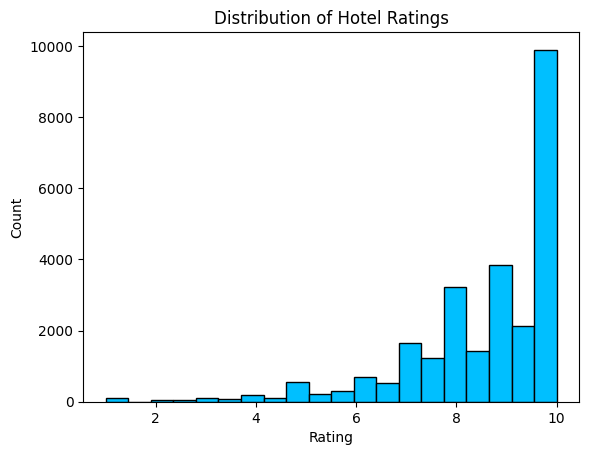

: 

: 

: 

: 

In [ ]:
plt.hist(df["rating"], bins=20, color='deepskyblue', edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Hotel Ratings")
plt.show()

распределение сильно скошено вправо, большинство значений рейтинга- 9 или 10. 

### Part 2 (1 pt)

Your only numerical feature so far (x variable) is the avg_rating variable, which is the average rating (over customers, I believe). Fit a simple regression model of rating on avg_rating. Report the R squared by completing the code in the following block

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

y = df.rating.values
X = df.avg_rating.values.reshape(len(y), 1)

model = LinearRegression() # has intercept by default
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


: 

: 

: 

: 

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)
print("Coefficient (slope):", round(model.coef_[0],3))
print("Intercept:", round(model.intercept_,3))
print("R^2:", round(r2_score(y, y_pred), 3))

Coefficient (slope): 1.029
Intercept: -0.136
R^2: 0.222


: 

: 

: 

: 

### Part 3 (2 pt)

The R squared is actually quite small. We will try to improve it using text analysis of the review_text variable. Run the code below

In [ ]:
from nltk.tokenize import WordPunctTokenizer
tokenizer = WordPunctTokenizer()

Z = [tokenizer.tokenize(z.lower()) for z in df.review_text]

: 

: 

: 

: 

In [ ]:
from gensim.models import Word2Vec

vector_size = 1000

model = Word2Vec(Z,
                 vector_size=vector_size,
                 min_count=5,
                 window=5).wv

: 

: 

: 

: 

In [ ]:
def convert_sentence(sentence):
    words = [w for w in sentence if w in model]
    if len(words) == 0:
        return np.zeros(vector_size)
    vector = np.mean([model[w] for w in words], axis=0)
    return vector

Z = np.array([convert_sentence(sentence) for sentence in Z])
X = df.loc[df.review_text.notna(), "avg_rating"].values.reshape(-1, 1)
X2 = np.hstack((X, Z))
y = df.loc[df.review_text.notna(), "rating"].values

print("X2 shape:", X2.shape)

X2 shape: (26386, 1001)


: 

: 

: 

: 

In [ ]:
model = LinearRegression()
model.fit(X2, y)

y_pred = model.predict(X2)

# Evaluate
print("Coefficient (slope):", round(model.coef_[0], 3))
print("Intercept:", round(model.intercept_, 3))
print("R^2 score:", round(r2_score(y, y_pred), 3))

Coefficient (slope): 0.783
Intercept: 1.495
R^2 score: 0.406


: 

: 

: 

: 

### Part 4 (2 points)

Your first (real) exercize is to build a 95% confidence interval for the main coefficient of the regression using bootstrap. Report the interval.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from tqdm import tqdm  # прогресс-бар

# Количество бутстреп-итераций
n_boot = 100
coefs = []

rng = np.random.default_rng(seed=42)

# Бутстреп с прогресс-баром
for _ in tqdm(range(n_boot), desc="Bootstrap progress"):
    # Случайная выборка индексов с возвращением
    sample_idx = rng.choice(len(y), size=len(y), replace=True)
    X_sample = X2[sample_idx]
    y_sample = y[sample_idx]
    
    # Обучаем модель на подвыборке
    model = LinearRegression().fit(X_sample, y_sample)
    coefs.append(model.coef_[0])  # сохраняем главный коэффициент

coefs = np.array(coefs)

# 95% доверительный интервал (2.5-й и 97.5-й процентили)
lower = np.percentile(coefs, 2.5)
upper = np.percentile(coefs, 97.5)

print(f"95% Confidence Interval for main coefficient: ({lower:.3f}, {upper:.3f})")


Bootstrap progress: 100%|██████████| 100/100 [03:00<00:00,  1.80s/it]

95% Confidence Interval for main coefficient: (0.755, 0.801)


: 

: 

: 

: 

### Part 5 (3 points)

Your second exercize is to find the optimal hyperparameters for the elastic net regression. Report the hyperparameters.

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from tqdm import tqdm
import itertools

elastic = ElasticNet(max_iter=5000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

# Все комбинации параметров
param_combinations = list(itertools.product(param_grid["alpha"], param_grid["l1_ratio"]))

results = []
for alpha, l1 in tqdm(param_combinations, desc="GridSearch progress"):
    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=5000)
    grid = GridSearchCV(model, {}, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X2, y)
    results.append((alpha, l1, grid.best_score_))

# Преобразуем в DataFrame
import pandas as pd
df_results = pd.DataFrame(results, columns=["alpha", "l1_ratio", "r2_score"])
best_row = df_results.loc[df_results["r2_score"].idxmax()]

print("Best hyperparameters:")
print(best_row)
print("R^2:", round(best_row["r2_score"], 3))

# Лучшая модель
best_model = ElasticNet(alpha=best_row["alpha"], l1_ratio=best_row["l1_ratio"], max_iter=5000)
best_model.fit(X2, y)
y_pred = best_model.predict(X2)
print("R^2 score on full data:", round(r2_score(y, y_pred), 3))


GridSearch progress:   0%|          | 0/42 [00:00<?, ?it/s]/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.821e+03, tolerance: 5.174e+00
  model = cd_fast.enet_coordinate_descent(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.907e+03, tolerance: 5.014e+00
  model = cd_fast.enet_coordinate_descent(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase t

Best hyperparameters:
alpha       0.001000
l1_ratio    0.100000
r2_score    0.317283
Name: 0, dtype: float64
R^2: 0.317
R^2 score on full data: 0.326


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.337e+03, tolerance: 6.475e+00
  model = cd_fast.enet_coordinate_descent(


: 

: 

: 

: 

### Part 6 (5 points)

Your third exercize is to run a 2SLS rregression, where on the first stage you use elastic net with the optimal hyperparameters. Report the main coefficient as part of the regression table.

In [ ]:
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm

# ----- Шаг 1. Используем оптимальные гиперпараметры из Part 5 -----
best_alpha = grid.best_params_['alpha']
best_l1 = grid.best_params_['l1_ratio']

print("Best hyperparameters from Part 5:")
print(f"alpha = {best_alpha}, l1_ratio = {best_l1}")

# ----- Шаг 1. Elastic Net (первая стадия) -----
print("\n[Stage 1] Training Elastic Net model...")
with tqdm(total=1, desc="Fitting ElasticNet") as pbar:
    stage1 = ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=5000)
    stage1.fit(X2, y)
    pbar.update(1)

# Предсказания с первой стадии (инструментальная переменная)
y_hat = stage1.predict(X2)

# ----- Шаг 2. Линейная регрессия (вторая стадия) -----
print("\n[Stage 2] Running OLS regression...")
with tqdm(total=1, desc="Fitting OLS") as pbar:
    stage2 = LinearRegression()
    stage2.fit(y_hat.reshape(-1, 1), y)
    pbar.update(1)

# Предсказания и оценка качества
y_pred_stage2 = stage2.predict(y_hat.reshape(-1, 1))
r2 = r2_score(y, y_pred_stage2)

# ----- Вывод результатов -----
print("\n2SLS Regression Results")
print("------------------------")
print(f"Main coefficient (beta): {stage2.coef_[0]:.3f}")
print(f"Intercept: {stage2.intercept_:.3f}")
print(f"R^2 score: {r2:.3f}")


: 

### Part 7 (10 points)

Construct a confidence interval for the main coefficient of the 2SLS  regression above. There are many details here, do not hesitate to consult AI. Write a short essay describing the details of the process.

### Part 8 (1 pt)

We will turn this into a classification problem now. Run the code below

In [ ]:
y2 = (y>5).astype(int)
y2 = 2*y2-1
y2.mean()

: 

: 

: 

: 

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # has intercept by default

: 

: 

: 

: 

In [ ]:
y2.mean()

: 

: 

: 

: 

In [ ]:
model.fit(X2, y2)
y_pred = model.predict(X2)

# Evaluate
print("Coefficient (slope):", round(model.coef_[0],3))
print("Intercept:", round(model.intercept_,3))

: 

: 

: 

: 

#### Part 9 (10 pt)

The logistic regression fails miserably. There are at least 2 reasons for this
- so many dimensions, risk of perfect separation
- very unbalanced data (because of the low threshold)

Your goal is to produce the best confidence interval for the main coefficient of the regression, but the code should converge in under (approximately) 60 seconds. Do it and time the code using %time magic command. Write a short essay explaining what you did.

note: you can not change the rating threshold, the data is unbalanced by nature, but you can use anything that we covered in lectures. please, do not use fancy packages, catboost or anything that you do not really understand

#### Part 10 (15 points)

There is one more reason why the logistic regression may fail --- the data is too noisy. I conjecture that the modified logistic regression (aka coin-flip logit) should take care of this. Try it (here) and write a short essay about the findings. There is no time limit.